<a href="https://colab.research.google.com/github/kubilaydemirsoy/greencart-analytics/blob/main/greencartanalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
import warnings

In [3]:
import warnings
import logging

# Python uyarılarını kapat
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Prophet ve Jupyter arka plan loglarını sessize al
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

In [4]:
%matplotlib inline
warnings.filterwarnings('ignore')

print("Kütüphaneler başarıyla yüklendi ve proje başlatıldı! 🌱")

Kütüphaneler başarıyla yüklendi ve proje başlatıldı! 🌱


In [5]:
df = pd.read_csv('ecommerce.csv', encoding='unicode_escape')

In [6]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [7]:
print("--- Veri Setinin İlk 5 Satırı ---")
display(df.head())

--- Veri Setinin İlk 5 Satırı ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [8]:
print("\n--- Veri Seti Yapısal Bilgileri (df.info) ---")
df.info()


--- Veri Seti Yapısal Bilgileri (df.info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [9]:
print("\n--- İstatistiksel Özet (df.describe) ---")
display(df.describe())


--- İstatistiksel Özet (df.describe) ---


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [10]:
essiz_urun_sayisi = df['StockCode'].nunique()
essiz_musteri_sayisi = df['CustomerID'].nunique()

In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [12]:
baslangic_tarihi = df['InvoiceDate'].min()
bitis_tarihi = df['InvoiceDate'].max()

In [13]:
print(f"Toplam Eşsiz Ürün Çeşidi: {essiz_urun_sayisi}")
print(f"Toplam Tekil Müşteri Sayısı: {essiz_musteri_sayisi}")
print(f"Verinin Kapsadığı Tarih Aralığı: {baslangic_tarihi} ile {bitis_tarihi} arası")
print("-" * 50)

Toplam Eşsiz Ürün Çeşidi: 4070
Toplam Tekil Müşteri Sayısı: 4372
Verinin Kapsadığı Tarih Aralığı: 2010-12-01 08:26:00 ile 2011-12-09 12:50:00 arası
--------------------------------------------------


<Figure size 1200x600 with 0 Axes>

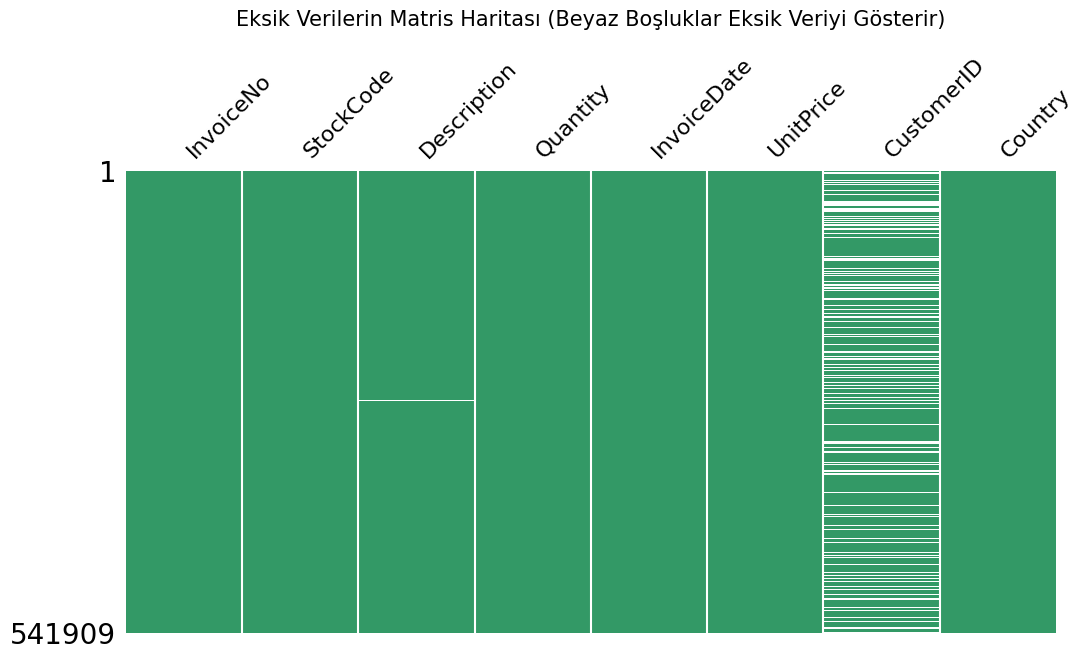

In [14]:
plt.figure(figsize=(12, 6))
msno.matrix(df, figsize=(12,6), sparkline=False, color=(0.2, 0.6, 0.4))
plt.title('Eksik Verilerin Matris Haritası (Beyaz Boşluklar Eksik Veriyi Gösterir)', fontsize=15, pad=20)
plt.show()

In [15]:
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df_iade = df[df['InvoiceNo'].str.startswith('C')].copy()

In [16]:
df_temiz = df[~df['InvoiceNo'].str.startswith('C')].copy()

In [17]:
df_temiz = df_temiz[(df_temiz['UnitPrice'] > 0) & (df_temiz['Quantity'] > 0)]

In [18]:
df_temiz.dropna(subset=['CustomerID'], inplace=True)

In [19]:
print(f"Orijinal Veri Satır Sayısı: {len(df)}")
print(f"Tespit Edilen İade/İptal (Karbon İsrafı) Satır Sayısı: {len(df_iade)}")
print(f"Temizlenmiş Geçerli Sipariş Satır Sayısı: {len(df_temiz)}")
print("-" * 50)
print("Veri başarıyla temizlendi ve iadeler ayrıştırıldı! ♻️")

Orijinal Veri Satır Sayısı: 541909
Tespit Edilen İade/İptal (Karbon İsrafı) Satır Sayısı: 9288
Temizlenmiş Geçerli Sipariş Satır Sayısı: 397884
--------------------------------------------------
Veri başarıyla temizlendi ve iadeler ayrıştırıldı! ♻️


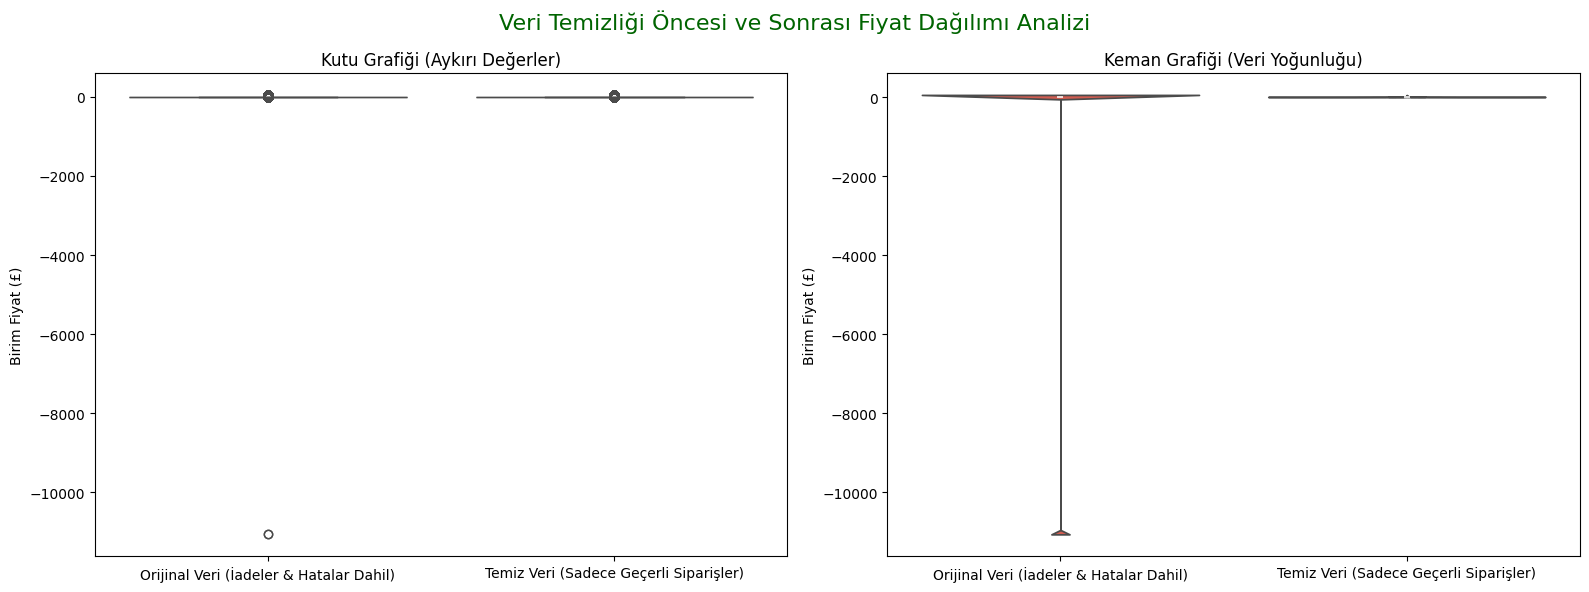

In [20]:
df_orijinal_gorsel = df[df['UnitPrice'] < 50].copy()
df_temiz_gorsel = df_temiz[df_temiz['UnitPrice'] < 50].copy()

df_orijinal_gorsel['Durum'] = 'Orijinal Veri (İadeler & Hatalar Dahil)'
df_temiz_gorsel['Durum'] = 'Temiz Veri (Sadece Geçerli Siparişler)'

df_karsilastirma = pd.concat([df_orijinal_gorsel, df_temiz_gorsel])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Veri Temizliği Öncesi ve Sonrası Fiyat Dağılımı Analizi', fontsize=16, color='darkgreen')

sns.boxplot(x='Durum', y='UnitPrice', data=df_karsilastirma, ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Kutu Grafiği (Aykırı Değerler)')
axes[0].set_ylabel('Birim Fiyat (£)')
axes[0].set_xlabel('')

sns.violinplot(x='Durum', y='UnitPrice', data=df_karsilastirma, ax=axes[1], palette=['#e74c3c', '#2ecc71'])
axes[1].set_title('Keman Grafiği (Veri Yoğunluğu)')
axes[1].set_ylabel('Birim Fiyat (£)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

In [21]:
top_satis = df_temiz.groupby('Description')['Quantity'].sum().reset_index()
top_satis.columns = ['Urun', 'Toplam_Satis']

In [22]:
top_iade = df_iade.groupby('Description')['Quantity'].sum().abs().reset_index()
top_iade.columns = ['Urun', 'Toplam_Iade']

In [23]:
df_urun_analiz = pd.merge(top_satis, top_iade, on='Urun', how='inner')

In [24]:
df_urun_analiz = df_urun_analiz[df_urun_analiz['Toplam_Satis'] > 100]

In [25]:
df_urun_analiz['Iade_Orani_Yuzde'] = (df_urun_analiz['Toplam_Iade'] / df_urun_analiz['Toplam_Satis']) * 100

In [26]:
en_cok_iade_edilenler = df_urun_analiz.sort_values(by='Iade_Orani_Yuzde', ascending=False).head(20)

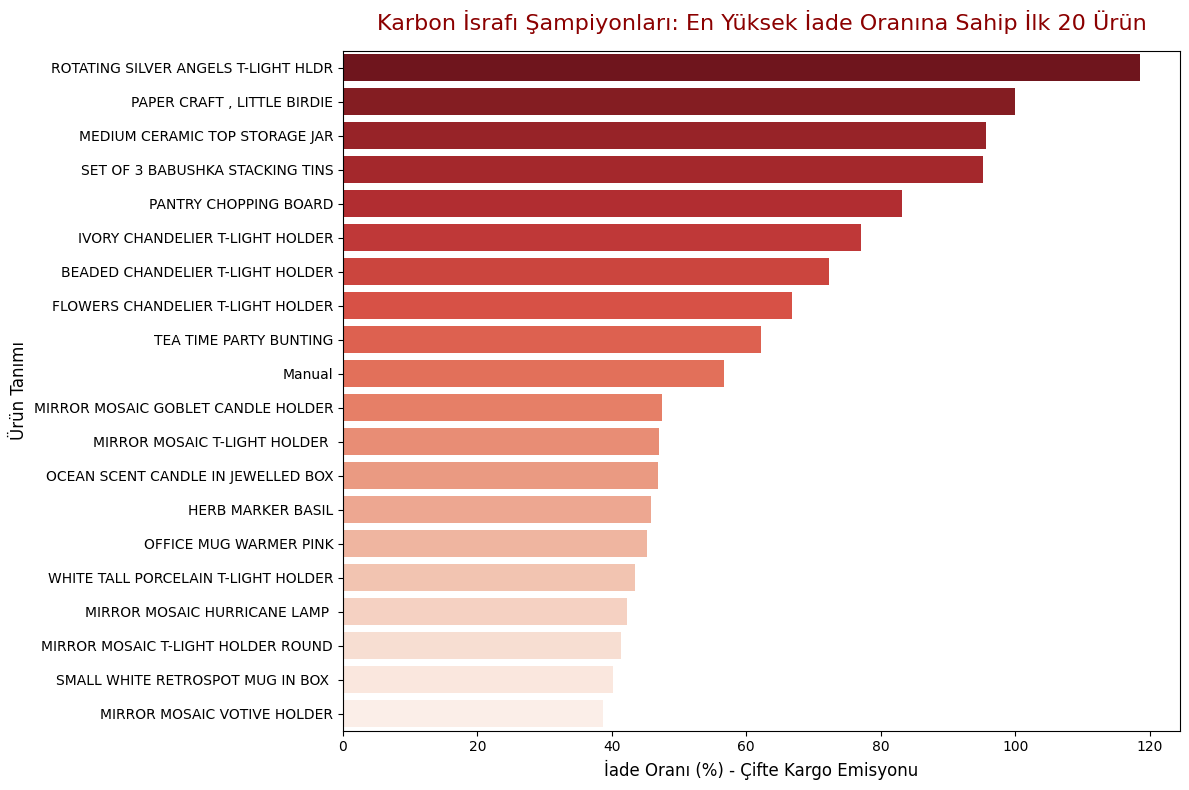

In [27]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Iade_Orani_Yuzde', y='Urun', data=en_cok_iade_edilenler, palette='Reds_r')

plt.title('Karbon İsrafı Şampiyonları: En Yüksek İade Oranına Sahip İlk 20 Ürün', fontsize=16, color='darkred', pad=15)
plt.xlabel('İade Oranı (%) - Çifte Kargo Emisyonu', fontsize=12)
plt.ylabel('Ürün Tanımı', fontsize=12)

plt.tight_layout()
plt.show()

In [28]:
df_temiz['Ay'] = df_temiz['InvoiceDate'].dt.month
df_temiz['Gun'] = df_temiz['InvoiceDate'].dt.day_name()

df_iade['Ay'] = df_iade['InvoiceDate'].dt.month
df_iade['Gun'] = df_iade['InvoiceDate'].dt.day_name()

In [29]:
aylik_satis = df_temiz.groupby('Ay')['Quantity'].sum().reset_index(name='Satis')
aylik_iade = df_iade.groupby('Ay')['Quantity'].sum().abs().reset_index(name='Iade')
df_aylik = pd.merge(aylik_satis, aylik_iade, on='Ay', how='left').fillna(0)
df_aylik['Iade_Orani'] = (df_aylik['Iade'] / df_aylik['Satis']) * 100

In [30]:
gunluk_satis = df_temiz.groupby('Gun')['Quantity'].sum().reset_index(name='Satis')
gunluk_iade = df_iade.groupby('Gun')['Quantity'].sum().abs().reset_index(name='Iade')
df_gunluk = pd.merge(gunluk_satis, gunluk_iade, on='Gun', how='left').fillna(0)
df_gunluk['Iade_Orani'] = (df_gunluk['Iade'] / df_gunluk['Satis']) * 100

In [31]:
gun_sirasi = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
df_gunluk['Gun'] = pd.Categorical(df_gunluk['Gun'], categories=gun_sirasi, ordered=True)
df_gunluk = df_gunluk.sort_values('Gun')

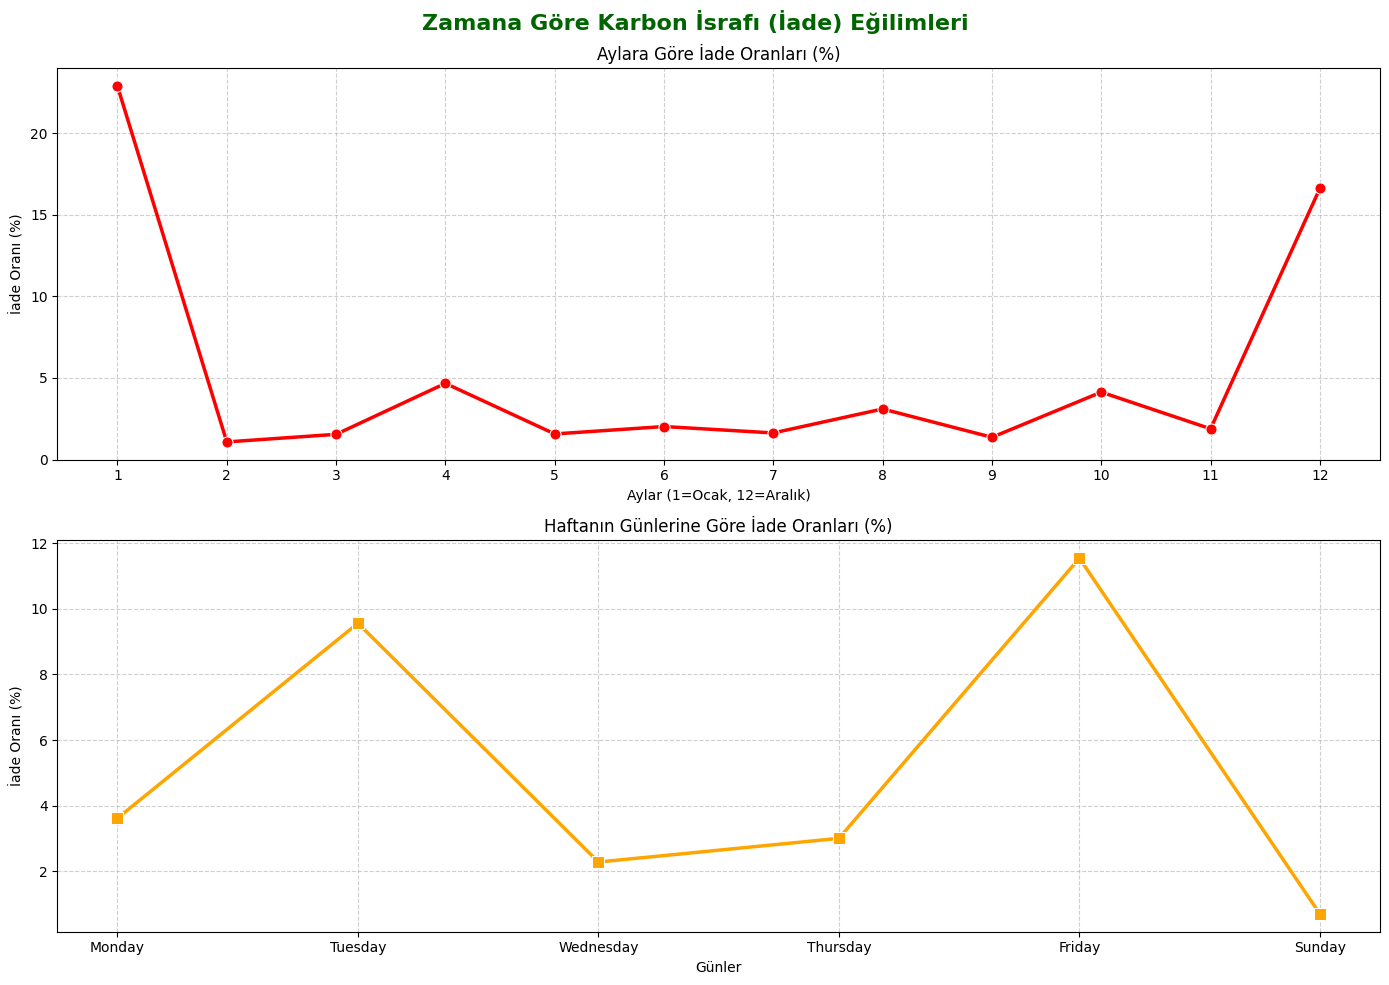

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Zamana Göre Karbon İsrafı (İade) Eğilimleri', fontsize=16, color='darkgreen', fontweight='bold')

sns.lineplot(ax=axes[0], x='Ay', y='Iade_Orani', data=df_aylik, marker='o', color='red', linewidth=2.5, markersize=8)
axes[0].set_title('Aylara Göre İade Oranları (%)', fontsize=12)
axes[0].set_ylabel('İade Oranı (%)')
axes[0].set_xlabel('Aylar (1=Ocak, 12=Aralık)')
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, linestyle='--', alpha=0.6)

sns.lineplot(ax=axes[1], x='Gun', y='Iade_Orani', data=df_gunluk, marker='s', color='orange', linewidth=2.5, markersize=8)
axes[1].set_title('Haftanın Günlerine Göre İade Oranları (%)', fontsize=12)
axes[1].set_ylabel('İade Oranı (%)')
axes[1].set_xlabel('Günler')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [33]:
df_yurtdisi = df_temiz[df_temiz['Country'] != 'United Kingdom'].copy()

In [34]:
ulke_bazli_satis = df_yurtdisi.groupby('Country').agg({
    'Quantity': 'sum',
    'InvoiceNo': 'nunique'
}).reset_index()

ulke_bazli_satis.columns = ['Ulke', 'Toplam_Urun_Hacmi', 'Toplam_Kargo_Sayisi']

In [35]:
mesafe_sozlugu = {
    'Germany': 900, 'France': 800, 'EIRE': 400, 'Spain': 1300,
    'Netherlands': 500, 'Belgium': 400, 'Switzerland': 1000,
    'Portugal': 1600, 'Australia': 15000, 'USA': 6800, 'Japan': 9500
}
ulke_bazli_satis['Mesafe_km'] = ulke_bazli_satis['Ulke'].map(mesafe_sozlugu).fillna(2000)

In [36]:
ulke_bazli_satis['Karbon_Skoru'] = (ulke_bazli_satis['Toplam_Urun_Hacmi'] * ulke_bazli_satis['Mesafe_km']) / 1000

en_yuksek_emisyon_ulkeleri = ulke_bazli_satis.sort_values(by='Karbon_Skoru', ascending=False).head(10)

print("--- En Yüksek Lojistik Karbon Ayak İzine Sahip İlk 5 Ülke ---")
display(en_yuksek_emisyon_ulkeleri.head(5))

--- En Yüksek Lojistik Karbon Ayak İzine Sahip İlk 5 Ülke ---


,Ulke,Toplam_Urun_Hacmi,Toplam_Kargo_Sayisi,Mesafe_km,Karbon_Skoru
0,Australia,83901,57,15000.0,1258515.0
19,Japan,26016,19,9500.0,247152.0
14,Germany,119261,457,900.0,107334.9
23,Netherlands,200361,94,500.0,100180.5
13,France,111471,389,800.0,89176.8


In [37]:
fig_3d_globe = px.choropleth(
    ulke_bazli_satis,
    locations="Ulke",
    locationmode="country names",
    color="Karbon_Skoru",
    hover_name="Ulke",
    color_continuous_scale=px.colors.sequential.Reds,
    projection="orthographic",
    title="🌍 3D Küresel Lojistik Karbon Ayak İzi Haritası"
)

fig_3d_globe.update_layout(
    margin={"r":0,"t":40,"l":0,"b":0},
    geo=dict(showocean=True, oceancolor="LightBlue", showland=True, landcolor="whitesmoke")
)

fig_3d_globe.show()

In [38]:
fig_3d_globe.show()

fig_treemap = px.treemap(
    ulke_bazli_satis.sort_values(by='Karbon_Skoru', ascending=False).head(15),
    path=['Ulke'],
    values='Karbon_Skoru',
    color='Karbon_Skoru',
    color_continuous_scale='Reds',
    title="Karbon Skoru Dağılımı (İlk 15 Ülke - Ağaç Haritası)"
)

fig_treemap.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig_treemap.show()

In [39]:
df_temiz['TotalPrice'] = df_temiz['Quantity'] * df_temiz['UnitPrice']

In [40]:
import datetime as dt
referans_tarihi = df_temiz['InvoiceDate'].max() + dt.timedelta(days=1)

In [41]:
green_rfm = df_temiz.groupby('CustomerID').agg({
    'InvoiceDate': lambda tarih: (referans_tarihi - tarih.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

green_rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [42]:
iade_sayilari = df_iade.groupby('CustomerID').agg({'InvoiceNo': 'nunique'}).reset_index()
iade_sayilari.columns = ['CustomerID', 'Return_Frequency']

green_rfm = pd.merge(green_rfm, iade_sayilari, on='CustomerID', how='left')
green_rfm['Return_Frequency'] = green_rfm['Return_Frequency'].fillna(0)

In [43]:
green_rfm['Iade_Orani'] = green_rfm['Return_Frequency'] / green_rfm['Frequency']
green_rfm['Kargo_Basina_Harcama'] = green_rfm['Monetary'] / green_rfm['Frequency']

In [44]:
def cevre_segmenti(row):
    if row['Frequency'] > 10 and row['Iade_Orani'] > 0.20:
        return 'Yüksek Karbon Ayak İzi (Riskli)'
    elif row['Kargo_Basina_Harcama'] > 300 and row['Iade_Orani'] == 0:
        return 'Çevre Dostu (Optimum Sepet)'
    else:
        return 'Standart Tüketici'

green_rfm['Segment'] = green_rfm.apply(cevre_segmenti, axis=1)

print("--- Green RFM Segmentasyon Sonuçları ---")
display(green_rfm['Segment'].value_counts())

--- Green RFM Segmentasyon Sonuçları ---


,count
Segment,
Standart Tüketici,3053
Çevre Dostu (Optimum Sepet),1150
Yüksek Karbon Ayak İzi (Riskli),135


In [45]:
from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [46]:
df_almanya = df_temiz[df_temiz['Country'] == 'Germany']

sepet = (df_almanya.groupby(['InvoiceNo', 'Description'])['Quantity']
         .sum().unstack().reset_index().fillna(0)
         .set_index('InvoiceNo'))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [47]:
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

sepet_encode = sepet.applymap(encode_units)

if 'POSTAGE' in sepet_encode.columns:
    sepet_encode.drop('POSTAGE', axis=1, inplace=True)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [48]:
frekansli_urunler = apriori(sepet_encode, min_support=0.05, use_colnames=True)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [49]:
kurallar = association_rules(frekansli_urunler, metric="lift", min_threshold=1)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [50]:
kurallar = kurallar.sort_values('confidence', ascending=False)

print("--- Lojistik Birleştirme İçin En Güçlü Ürün Kombinasyonları (İlk 5 Kural) ---")
display(kurallar[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

--- Lojistik Birleştirme İçin En Güçlü Ürün Kombinasyonları (İlk 5 Kural) ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

,antecedents,consequents,support,confidence,lift
11,(RED RETROSPOT CHARLOTTE BAG),(WOODLAND CHARLOTTE BAG),0.059081,0.843750,6.648168
12,(ROUND SNACK BOXES SET OF 4 FRUITS ),(ROUND SNACK BOXES SET OF4 WOODLAND ),0.131291,0.833333,3.400298
14,(SPACEBOY LUNCH BOX ),(ROUND SNACK BOXES SET OF4 WOODLAND ),0.070022,0.680851,2.778116
0,(PLASTERS IN TIN CIRCUS PARADE ),(PLASTERS IN TIN WOODLAND ANIMALS),0.067834,0.584906,4.242887
7,(PLASTERS IN TIN SPACEBOY),(PLASTERS IN TIN WOODLAND ANIMALS),0.061269,0.571429,4.145125


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [51]:
import networkx as nx
import plotly.graph_objects as go

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [52]:
top_kurallar = kurallar.sort_values('lift', ascending=False).head(25)

G = nx.DiGraph()
for i, row in top_kurallar.iterrows():
    kaynak = list(row['antecedents'])[0]
    hedef = list(row['consequents'])[0]
    G.add_edge(kaynak, hedef, weight=row['lift'])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [53]:
pos = nx.spring_layout(G, seed=42)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [54]:
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=1.5, color='#888'),
    hoverinfo='none',
    mode='lines')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [55]:
node_x = []
node_y = []
text_list = []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    text_list.append(node)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    text=text_list,
    textposition="top center",
    hoverinfo='text',
    marker=dict(
        showscale=True,
        colorscale='YlGn',
        color=[],
        size=22,
        line_width=2))

node_adjacencies = []
for node, adjacencies in enumerate(G.adjacency()):
    node_adjacencies.append(len(adjacencies[1]))
node_trace.marker.color = node_adjacencies

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [56]:
fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title='🌱 Akıllı Lojistik: İnteraktif Ürün Ağ Haritası (Kargo Birleştirme Fırsatları)',
                titlefont_size=16,
                showlegend=False,
                hovermode='closest',
                margin=dict(b=20,l=5,r=5,t=40),
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                )
fig.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [57]:
from prophet import Prophet

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [58]:
gunluk_satis = df_temiz.groupby(df_temiz['InvoiceDate'].dt.date)['Quantity'].sum().reset_index()
gunluk_satis.columns = ['ds', 'y']

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [59]:
model = Prophet(interval_width=0.95, daily_seasonality=False)
model.fit(gunluk_satis)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [60]:
gelecek_tarihler = model.make_future_dataframe(periods=90)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [61]:
tahminler = model.predict(gelecek_tarihler)
print("--- Gelecek 90 Gün İçin Optimizasyon (Talep Tahmini) Çıktısı ---")
display(tahminler[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

--- Gelecek 90 Gün İçin Optimizasyon (Talep Tahmini) Çıktısı ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



,ds,yhat,yhat_lower,yhat_upper
390,2012-03-04,29319.634279,13112.299386,44685.991457
391,2012-03-05,36324.686253,20420.199912,51811.941812
392,2012-03-06,39630.190816,23768.567009,56069.771316
393,2012-03-07,38511.145828,24166.817111,54007.665393
394,2012-03-08,42189.256011,26636.147779,58237.197157


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [62]:
from prophet.plot import plot_plotly, plot_components_plotly

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [63]:
fig_forecast = plot_plotly(model, tahminler)

fig_forecast.update_layout(
    title='📅 Akıllı Stok Tahmini: Gelecek 90 Günlük Optimum Talep ve Sıfır Atık Sınırları',
    titlefont_size=18,
    xaxis_title='Zaman (Tarih)',
    yaxis_title='Günlük Toplam Ürün Talebi (Adet)',
    plot_bgcolor='whitesmoke',
    hovermode='x unified'
)

fig_forecast.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [64]:
fig_components = plot_components_plotly(model, tahminler)
fig_components.update_layout(title='Gelecek Tahmini Bileşenleri (Genel Trend ve Haftalık Sezonallik)')
fig_components.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [65]:
df_temiz['Saat'] = df_temiz['InvoiceDate'].dt.hour

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [66]:
yogunluk_verisi = df_temiz.groupby(['Gun', 'Saat'])['InvoiceNo'].nunique().reset_index()
yogunluk_verisi.columns = ['Gun', 'Saat', 'Siparis_Sayisi']

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [67]:
pivot_yogunluk = yogunluk_verisi.pivot(index='Gun', columns='Saat', values='Siparis_Sayisi').fillna(0)
gun_sirasi = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
pivot_yogunluk = pivot_yogunluk.reindex(gun_sirasi)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

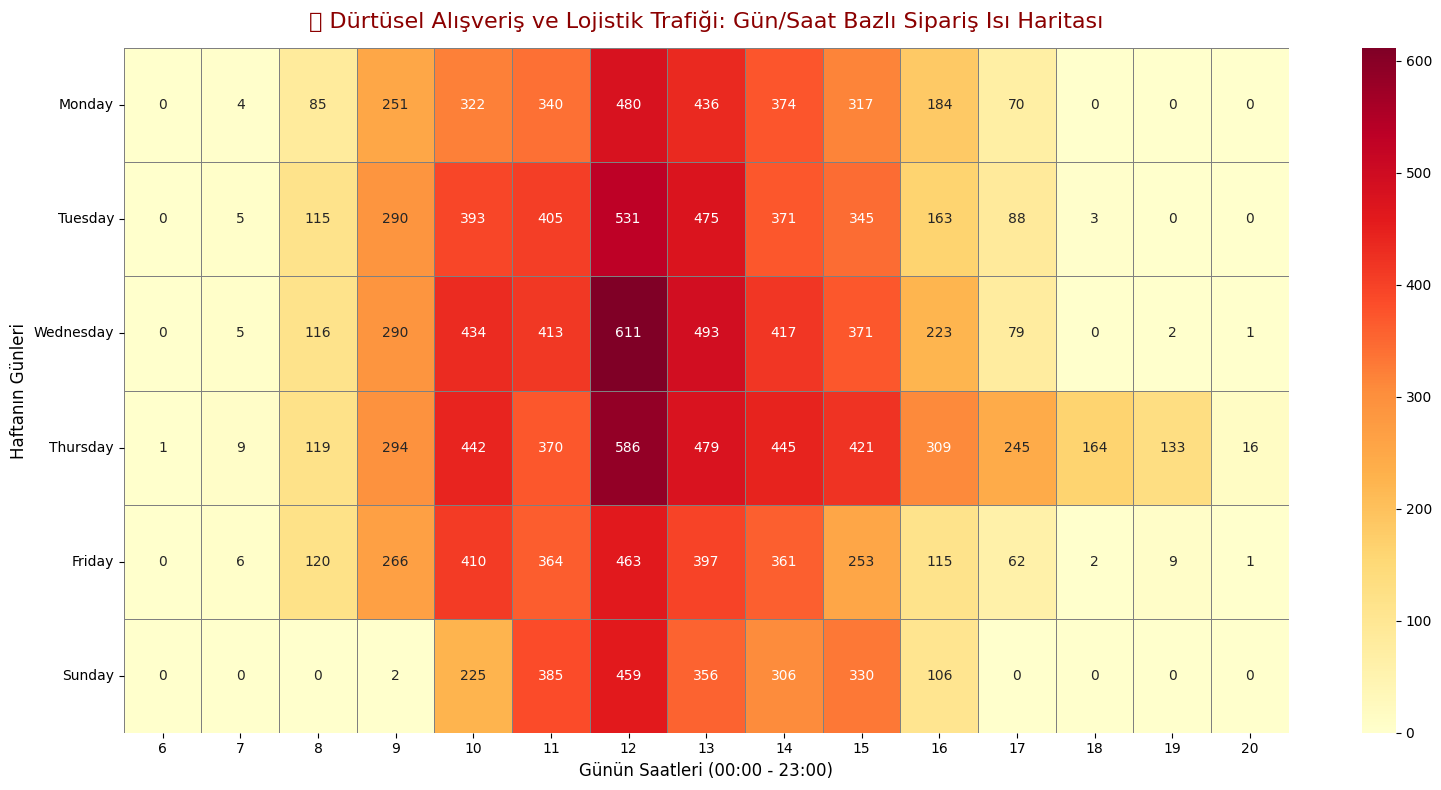

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [68]:
plt.figure(figsize=(16, 8))
sns.heatmap(pivot_yogunluk, cmap='YlOrRd', linewidths=0.5, linecolor='gray', annot=True, fmt=".0f")
plt.title('🔥 Dürtüsel Alışveriş ve Lojistik Trafiği: Gün/Saat Bazlı Sipariş Isı Haritası', fontsize=16, color='darkred', pad=15)
plt.xlabel('Günün Saatleri (00:00 - 23:00)', fontsize=12)
plt.ylabel('Haftanın Günleri', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [69]:
df_iade['Saat'] = df_iade['InvoiceDate'].dt.hour

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [70]:
iade_yogunluk = df_iade.groupby(['Gun', 'Saat'])['InvoiceNo'].nunique().reset_index()
iade_yogunluk.columns = ['Gun', 'Saat', 'Iade_Sayisi']

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [71]:
pivot_iade = iade_yogunluk.pivot(index='Gun', columns='Saat', values='Iade_Sayisi').fillna(0)
gun_sirasi = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
pivot_iade = pivot_iade.reindex(gun_sirasi)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

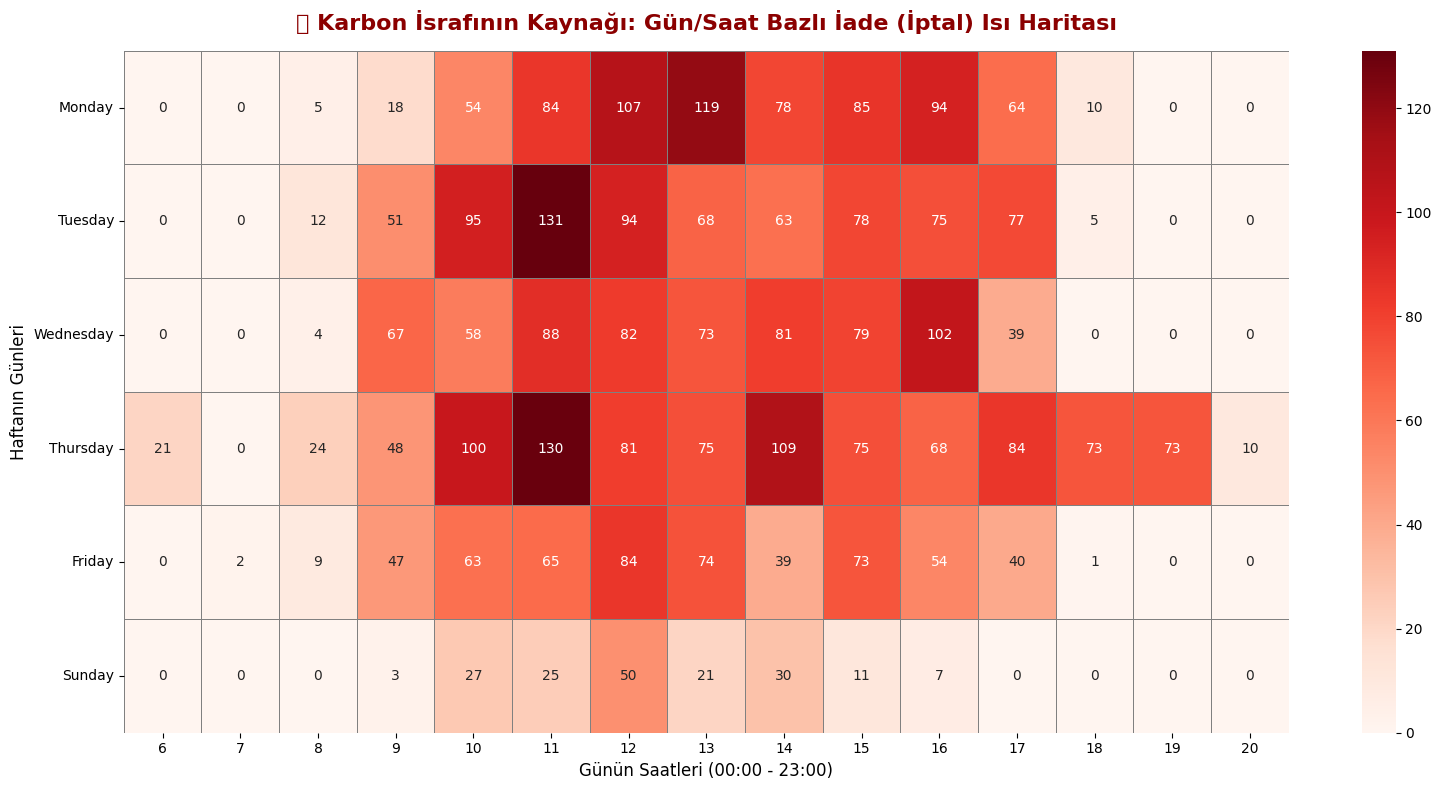

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [72]:
plt.figure(figsize=(16, 8))
sns.heatmap(pivot_iade, cmap='Reds', linewidths=0.5, linecolor='gray', annot=True, fmt=".0f")
plt.title('🚨 Karbon İsrafının Kaynağı: Gün/Saat Bazlı İade (İptal) Isı Haritası', fontsize=16, color='darkred', fontweight='bold', pad=15)
plt.xlabel('Günün Saatleri (00:00 - 23:00)', fontsize=12)
plt.ylabel('Haftanın Günleri', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()